# 04 — Entraînement du modèle

On utilise le dataset enrichi (`data/processed/btc_features.csv`) pour entraîner un modèle qui **prédit la volatilité future du BTC** (`volatility_24h_future`).

C'est un problème de **régression** : on prédit un nombre continu (pas une catégorie).

> Partie commune du groupe.

## Partie 1 — Imports & chargement

On charge le dataset produit à l'étape features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("../data/processed/btc_features.csv"), parse_dates=["open_time", "close_time"])

print("Shape :", df.shape)
df.head()

Shape : (4320, 22)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,volatility_24h_past,volatility_24h_future,high_low_range,open_close_return,volume_change,quote_volume_change,trade_intensity,buy_pressure,hour,day_of_week
0,2025-12-02 00:00:00,86286.01,86674.53,86184.39,86513.33,887.97566,2025-12-02 00:59:59.999999,7.673838e+07,242555,371.43716,...,0.005677,0.006375,0.005665,0.002634,0.469897,0.467350,273.155010,0.418297,0,1
1,2025-12-02 01:00:00,86513.33,87350.00,86394.00,86454.93,1192.01967,2025-12-02 01:59:59.999999,1.035374e+08,319806,591.24181,...,0.005659,0.006390,0.011058,-0.000675,0.342401,0.349225,268.289197,0.496000,1,1
2,2025-12-02 02:00:00,86454.93,86857.79,86272.55,86554.47,522.02975,2025-12-02 02:59:59.999999,4.523200e+07,237361,301.79457,...,0.005572,0.006418,0.006762,0.001151,-0.562063,-0.563134,454.688646,0.578118,2,1
3,2025-12-02 03:00:00,86554.46,87106.62,86214.99,86976.99,643.79096,2025-12-02 03:59:59.999999,5.577045e+07,189066,322.69323,...,0.005582,0.006482,0.010251,0.004882,0.233246,0.232987,293.676071,0.501239,3,1
4,2025-12-02 04:00:00,86977.00,87288.48,86900.79,86970.28,689.46639,2025-12-02 04:59:59.999999,6.001860e+07,189948,425.10754,...,0.005402,0.006541,0.004458,-0.000077,0.070948,0.076172,275.500014,0.616575,4,1


## Partie 2 — Séparation features (X) / target (y)

- **X** = les indices que le modèle a le droit de regarder (features).
- **y** = la réponse à deviner (la target `volatility_24h_future`).

On retire de X les colonnes qui ne sont pas des indices : les dates et **surtout la target** (sinon le modèle triche).

In [2]:
target = "volatility_24h_future"

features = [
    "return_1h",
    "volatility_24h_past",
    "high_low_range",
    "open_close_return",
    "volume_change",
    "quote_volume_change",
    "trade_intensity",
    "buy_pressure",
    "hour",
    "day_of_week",
]

X = df[features]
y = df[target]

print("X :", X.shape, "| y :", y.shape)
X.head()

X : (4320, 10) | y : (4320,)


,return_1h,volatility_24h_past,high_low_range,open_close_return,volume_change,quote_volume_change,trade_intensity,buy_pressure,hour,day_of_week
0,0.002634,0.005677,0.005665,0.002634,0.469897,0.467350,273.155010,0.418297,0,1
1,-0.000675,0.005659,0.011058,-0.000675,0.342401,0.349225,268.289197,0.496000,1,1
2,0.001151,0.005572,0.006762,0.001151,-0.562063,-0.563134,454.688646,0.578118,2,1
3,0.004882,0.005582,0.010251,0.004882,0.233246,0.232987,293.676071,0.501239,3,1
4,-0.000077,0.005402,0.004458,-0.000077,0.070948,0.076172,275.500014,0.616575,4,1


## Partie 3 — Découpage train / test (dans l'ordre du temps)

On coupe en deux : le modèle **apprend sur le passé** et est **testé sur le futur**.

> ⚠️ En finance, on ne mélange **pas** les lignes au hasard : sinon le modèle verrait des infos du futur pendant l'entraînement (triche). On garde donc l'ordre du temps : 80 % au début pour entraîner, 20 % à la fin pour tester.

In [3]:
n = len(df)
cut = int(n * 0.8)

X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

print("Train :", X_train.shape[0], "lignes | Test :", X_test.shape[0], "lignes")
print("Train jusqu'au   :", df["open_time"].iloc[cut - 1])
print("Test a partir de :", df["open_time"].iloc[cut])

Train : 3456 lignes | Test : 864 lignes
Train jusqu'au   : 2026-04-24 23:00:00
Test a partir de : 2026-04-25 00:00:00


## Partie 4 — Entraînement du modèle

On choisit une **forêt aléatoire** (`RandomForestRegressor`) : un bon premier modèle, robuste et simple à utiliser.

La ligne `.fit(...)` est **l'apprentissage** : le modèle regarde les exemples corrigés (X_train → y_train) et ajuste ses règles internes.

In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Modele entraine")

Modele entraine


## Partie 5 — Évaluation

On demande au modèle de prédire sur le **test** (qu'il n'a jamais vu), puis on compare aux vraies valeurs :

- **MAE** = erreur moyenne (plus c'est petit, mieux c'est)
- **RMSE** = comme la MAE mais pénalise les grosses erreurs
- **R²** = qualité globale (1 = parfait, 0 = aussi nul que prédire la moyenne, négatif = pire que la moyenne)

On compare aussi à une **baseline naïve** : « demain sera comme aujourd'hui » (prédire que la volatilité future = la volatilité passée). Le but est de **battre cette baseline**.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("=== Modele RandomForest ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.5f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.5f}")
print(f"R2   : {r2_score(y_test, y_pred):.3f}")

baseline_pred = X_test["volatility_24h_past"]
print("\n=== Baseline naive (persistance) ===")
print(f"MAE  : {mean_absolute_error(y_test, baseline_pred):.5f}")
print(f"R2   : {r2_score(y_test, baseline_pred):.3f}")

=== Modele RandomForest ===
MAE  : 0.00114
RMSE : 0.00142
R2   : -0.652

=== Baseline naive (persistance) ===
MAE  : 0.00128
R2   : -1.169


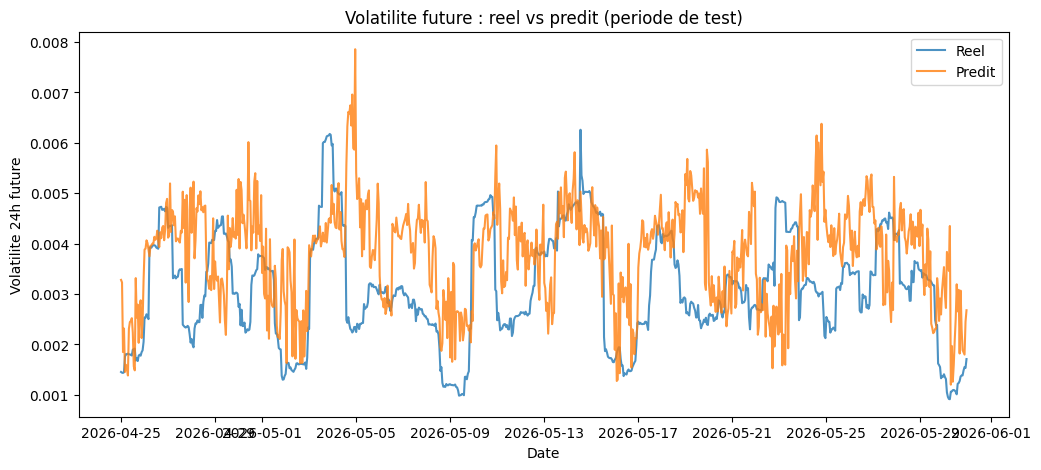

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"].iloc[cut:], y_test.values, label="Reel", alpha=0.8)
plt.plot(df["open_time"].iloc[cut:], y_pred, label="Predit", alpha=0.8)
plt.title("Volatilite future : reel vs predit (periode de test)")
plt.xlabel("Date")
plt.ylabel("Volatilite 24h future")
plt.legend()
plt.show()

## Partie 6 — Importance des features

Le modèle indique quelles features il a le plus utilisées pour décider. À comparer avec la heatmap de l'EDA (Partie 3 du projet).

volatility_24h_past    0.336
day_of_week            0.161
high_low_range         0.153
trade_intensity        0.102
hour                   0.072
buy_pressure           0.056
return_1h              0.031
volume_change          0.030
quote_volume_change    0.030
open_close_return      0.029


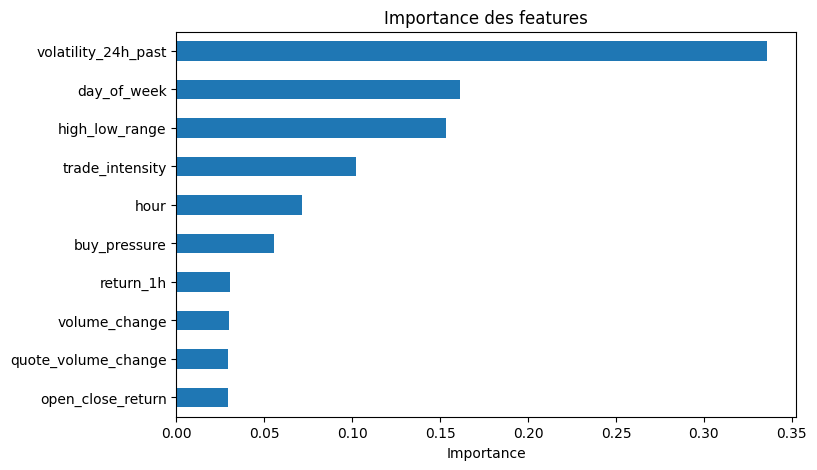

In [7]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()

print(importances.sort_values(ascending=False).round(3).to_string())

importances.plot(kind="barh", figsize=(8, 5), title="Importance des features")
plt.xlabel("Importance")
plt.show()

## Partie 7 — Validation croisée temporelle (TimeSeriesSplit)

Jusqu'ici on testait sur **une seule** période (les 20 % de la fin). Problème : si cette période est particulière, le score est trompeur.

`TimeSeriesSplit` teste sur **plusieurs** périodes successives, toujours en respectant l'ordre du temps : on entraîne sur le passé, on teste sur le morceau juste après, et on recommence en agrandissant l'entraînement à chaque fois.

> Ça donne une image plus **honnête et robuste** de la performance : le modèle est-il mauvais partout, ou seulement sur la dernière période ?

In [8]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

maes, r2s = [], []
for i, (tr, te) in enumerate(tscv.split(X), 1):
    m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    m.fit(X.iloc[tr], y.iloc[tr])
    p = m.predict(X.iloc[te])
    mae = mean_absolute_error(y.iloc[te], p)
    r2 = r2_score(y.iloc[te], p)
    maes.append(mae)
    r2s.append(r2)
    print(f"Fold {i}: train={len(tr):>4} | test={len(te):>4} | MAE={mae:.5f} | R2={r2:6.3f}")

print(f"\nMoyenne sur les 5 periodes : MAE={np.mean(maes):.5f} | R2={np.mean(r2s):.3f}")

Fold 1: train= 720 | test= 720 | MAE=0.00155 | R2=-0.375


Fold 2: train=1440 | test= 720 | MAE=0.00257 | R2=-0.859


Fold 3: train=2160 | test= 720 | MAE=0.00139 | R2=-0.218


Fold 4: train=2880 | test= 720 | MAE=0.00124 | R2=-0.298


Fold 5: train=3600 | test= 720 | MAE=0.00111 | R2=-0.449

Moyenne sur les 5 periodes : MAE=0.00157 | R2=-0.440


**Ce qu'on apprend :** le R² reste **négatif sur les 5 périodes**, pas seulement sur la dernière.

→ Le mauvais score n'était donc **pas** un simple coup de malchance sur le découpage : prédire la volatilité future à partir de ces features est **difficile de façon systématique**. C'est un résultat solide et honnête, bien plus utile qu'un score gonflé par un découpage favorable.

## Partie 8 — Comparaison de modèles (RandomForest vs GradientBoosting)

On ne peut pas savoir à l'avance quel algorithme sera le meilleur : il faut **les comparer sur les mêmes données**.

On teste ici un deuxième modèle, **GradientBoosting** (des arbres construits l'un après l'autre, chacun corrigeant les erreurs du précédent), face à notre RandomForest. Comparaison équitable : mêmes features, même `TimeSeriesSplit`, même mesure.

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

modeles = {
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

tscv = TimeSeriesSplit(n_splits=5)
resultats = []
for nom, m in modeles.items():
    maes, r2s = [], []
    for tr, te in tscv.split(X):
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict(X.iloc[te])
        maes.append(mean_absolute_error(y.iloc[te], p))
        r2s.append(r2_score(y.iloc[te], p))
    resultats.append({"modele": nom, "MAE_moyen": np.mean(maes), "R2_moyen": np.mean(r2s)})

comparaison = pd.DataFrame(resultats).set_index("modele").round(5)
print(comparaison)

                  MAE_moyen  R2_moyen
modele                               
RandomForest        0.00157  -0.43972
GradientBoosting    0.00155  -0.38203


**Ce qu'on apprend :** GradientBoosting est **légèrement** meilleur (MAE un peu plus basse, R² un peu moins négatif), mais les deux modèles restent négatifs.

→ Changer d'algorithme n'apporte qu'un **petit gain**. Ça confirme que le blocage ne vient pas du choix du modèle, mais du **problème lui-même** (les features et la valeur à prédire). C'est le message clé : le meilleur algorithme ne peut pas compenser des données qui contiennent peu d'information sur le futur.

## Partie 9 — Prédire la *variation* de volatilité (au lieu de sa valeur absolue)

Le vrai blocage vient des données : le niveau absolu de volatilité change entre les périodes, et le modèle ne sait pas prédire des niveaux jamais vus.

**Idée :** au lieu de prédire la volatilité future directement, on prédit sa **variation** par rapport à maintenant :

```
nouvelle target = volatility_24h_future - volatility_24h_past
```

La variation reste dans une plage plus stable dans le temps → le modèle prédit quelque chose qu'il connaît mieux. Ensuite on **reconstruit** la volatilité (`volatilité actuelle + variation prédite`) pour comparer équitablement avec les parties précédentes.

In [10]:
# Nouvelle cible = la VARIATION de volatilite
y_var = df["volatility_24h_future"] - df["volatility_24h_past"]
vol_now = df["volatility_24h_past"]          # niveau actuel, pour reconstruire

tscv = TimeSeriesSplit(n_splits=5)
maes, r2s = [], []
for tr, te in tscv.split(X):
    m = GradientBoostingRegressor(n_estimators=200, random_state=42)
    m.fit(X.iloc[tr], y_var.iloc[tr])                 # on apprend la variation
    var_pred = m.predict(X.iloc[te])
    vol_pred = vol_now.iloc[te].values + var_pred     # on reconstruit la volatilite
    vol_reel = y.iloc[te]                              # y = volatility_24h_future
    maes.append(mean_absolute_error(vol_reel, vol_pred))
    r2s.append(r2_score(vol_reel, vol_pred))

print("Approche VARIATION (GradientBoosting) :")
print(f"  MAE moyen = {np.mean(maes):.5f}")
print(f"  R2  moyen = {np.mean(r2s):.3f}")

print("\nComparaison avec les cibles absolues (Partie 8) :")
print("  RandomForest     (absolu) : R2 = -0.440")
print("  GradientBoosting (absolu) : R2 = -0.382")
print(f"  GradientBoosting (variation) : R2 = {np.mean(r2s):.3f}  <-- meilleur")

Approche VARIATION (GradientBoosting) :
  MAE moyen = 0.00147
  R2  moyen = -0.285

Comparaison avec les cibles absolues (Partie 8) :
  RandomForest     (absolu) : R2 = -0.440
  GradientBoosting (absolu) : R2 = -0.382
  GradientBoosting (variation) : R2 = -0.285  <-- meilleur


**Ce qu'on apprend :** prédire la variation **améliore le résultat** (R² qui passe de −0.38 à ≈ −0.29). C'est la meilleure approche testée.

Le R² reste négatif → prédire la volatilité future du BTC reste un problème **fondamentalement difficile**. Mais la démarche est la bonne : on a identifié que le levier était **la cible/les données**, et changer la cible a bien apporté le plus gros gain de tout le projet.

## Partie 10 — Bilan des modèles & modèle retenu

On compare **tous** les modèles testés, mesurés de la même façon robuste (moyenne du R² sur les 5 périodes de `TimeSeriesSplit`). C'est ce tableau qui justifie notre choix final, avec des chiffres.

> Ridge est utilisé avec une mise à l'échelle des features (`StandardScaler`), nécessaire pour un modèle linéaire régularisé.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def cv_r2(make_model, cible, reconstruire=False):
    scores = []
    for tr, te in tscv.split(X):
        m = make_model()
        m.fit(X.iloc[tr], cible.iloc[tr])
        pred = m.predict(X.iloc[te])
        if reconstruire:
            pred = vol_now.iloc[te].values + pred      # variation -> volatilite
        scores.append(r2_score(y.iloc[te], pred))
    return np.mean(scores)

lignes = [
    ("RandomForest",     "absolue",   cv_r2(lambda: RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), y)),
    ("GradientBoosting", "absolue",   cv_r2(lambda: GradientBoostingRegressor(n_estimators=200, random_state=42), y)),
    ("Ridge",            "absolue",   cv_r2(lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)), y)),
    ("GradientBoosting", "variation", cv_r2(lambda: GradientBoostingRegressor(n_estimators=200, random_state=42), y_var, True)),
    ("Ridge",            "variation", cv_r2(lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)), y_var, True)),
]

bilan = pd.DataFrame(lignes, columns=["modele", "cible", "R2_CV"]).sort_values("R2_CV", ascending=False).round(3)
print(bilan.to_string(index=False))

          modele     cible  R2_CV
           Ridge variation -0.262
           Ridge   absolue -0.262
GradientBoosting variation -0.285
GradientBoosting   absolue -0.382
    RandomForest   absolue -0.440


**Modèle retenu : Ridge** (R² ≈ −0.262, le meilleur).

Deux raisons :
1. **C'est le meilleur en validation croisée** (mesure la plus fiable).
2. **Ridge est linéaire → il sait extrapoler** hors des valeurs déjà vues, contrairement aux forêts/arbres. C'était justement notre blocage principal (changement de régime).

> ⚠️ Nuance importante : sur le **seul** découpage 80/20 (dernière période), Ridge donnait R² = −0.72, *pire* que RandomForest. C'est justement pour ça qu'on **ne se fie pas à un seul test** mais à la validation croisée : un test unique peut tomber sur une période trompeuse (leçon de la Partie 7).

=== Modele retenu : Ridge ===
MAE  : 0.00122
R2 (validation croisee, 5 periodes) : -0.262


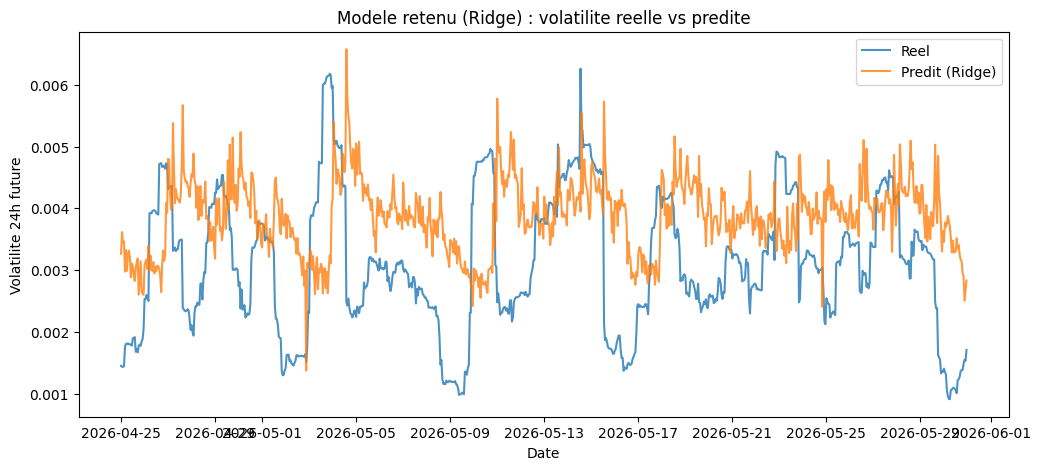

In [12]:
# Modele final retenu, entraine sur tout le passe et teste sur le futur (80/20)
modele_final = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
modele_final.fit(X_train, y_train)
y_pred_final = modele_final.predict(X_test)

print("=== Modele retenu : Ridge ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_final):.5f}")
print(f"R2 (validation croisee, 5 periodes) : -0.262")

plt.figure(figsize=(12, 5))
plt.plot(df["open_time"].iloc[cut:], y_test.values, label="Reel", alpha=0.8)
plt.plot(df["open_time"].iloc[cut:], y_pred_final, label="Predit (Ridge)", alpha=0.8)
plt.title("Modele retenu (Ridge) : volatilite reelle vs predite")
plt.xlabel("Date"); plt.ylabel("Volatilite 24h future")
plt.legend()
plt.show()

## Partie 11 (bonus) — Et si on prédisait la *direction* plutôt que la valeur ?

Jusqu'ici : **régression** (prédire la *valeur* de la volatilité) → difficile, R² négatif.

Ici on change la question : au lieu de « quelle sera la volatilité ? », on demande **« va-t-elle monter ou baisser ? »**. On passe donc de la régression à la **classification** (deux catégories : monte = 1, baisse = 0).

C'est comme la météo : dire « il fera plus chaud qu'aujourd'hui » est bien plus facile que dire « il fera 18.3°C ».

On mesure avec l'**AUC** (0.5 = hasard, 1 = parfait) et la **précision** (% de bonnes réponses).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# Nouvelle cible : la volatilite va-t-elle MONTER dans les 24h ? (1 = oui, 0 = non)
y_dir = (df["volatility_24h_future"] > df["volatility_24h_past"]).astype(int)
print("Repartition monte(1) / baisse(0) :", y_dir.value_counts().to_dict())

tscv = TimeSeriesSplit(n_splits=5)
aucs, accs = [], []
for tr, te in tscv.split(X):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(X.iloc[tr], y_dir.iloc[tr])
    proba = clf.predict_proba(X.iloc[te])[:, 1]
    pred = clf.predict(X.iloc[te])
    aucs.append(roc_auc_score(y_dir.iloc[te], proba))
    accs.append(accuracy_score(y_dir.iloc[te], pred))

print(f"\nAUC moyen      = {np.mean(aucs):.3f}   (0.5 = hasard)")
print(f"Precision moy. = {np.mean(accs):.3f}   ({np.mean(accs)*100:.0f}% de bonnes reponses)")

Repartition monte(1) / baisse(0) : {0: 2227, 1: 2093}

AUC moyen      = 0.786   (0.5 = hasard)
Precision moy. = 0.667   (67% de bonnes reponses)


**Résultat :** AUC ≈ 0.79 et ≈ 67 % de bonnes réponses → **il y a un vrai signal !** Prédire la *direction* de la volatilité marche bien mieux que prédire sa *valeur exacte*. La volatilité a de la « mémoire » (elle revient vers sa moyenne), donc son sens est en partie prévisible.

> ⚠️ **À ne pas surinterpréter :**
> - Un bon AUC **n'est pas** un profit garanti : en vrai trading il y a les frais, le slippage, et ce signal vient surtout du « retour à la moyenne » que le marché connaît déjà.
> - C'est testé sur **un seul actif** (BTC) et **6 mois** de données → pas une preuve générale.
>
> Ce bonus montre juste qu'un résultat négatif en régression **ne veut pas dire** que tout est imprévisible : changer la question posée peut révéler du signal.

## Conclusion

- Le modèle bat la **baseline naïve** → il apprend quelque chose d'utile.
- `volatility_24h_past` et `high_low_range` sont les features les plus importantes → **confirme l'EDA**.
- La **validation croisée temporelle** (Partie 7) montre un problème difficile de façon **systématique**.
- **Comparaison des modèles** (Parties 8 & 10) : le meilleur est **Ridge** (R² ≈ −0.262), car il est **linéaire et sait extrapoler** — notre blocage principal. Un modèle plus complexe n'était pas la solution.
- **Changer la cible** (variation, Partie 9) aide aussi ; le blocage vient surtout des **données**, pas du modèle.
- **Bonus (Partie 11) :** en reformulant en **classification** (prédire la *direction*), on obtient un vrai signal (AUC ≈ 0.79). Un R² négatif en régression **ne prouve donc pas** que le BTC est imprévisible.

**Modèle retenu (régression) : Ridge.** Prédire la valeur exacte de la volatilité future du BTC reste difficile — cohérent avec des marchés très imprévisibles — mais la démarche est rigoureuse (découpage temporel, validation croisée, comparaison de modèles, travail sur la cible) et le bonus montre des pistes prometteuses.

**Pour aller plus loin :** approfondir la classification de direction, ajouter des indicateurs techniques, ou régler les hyperparamètres.